In [1]:
from notus import utils, ByteLevelTokenizer, eval, CompressionEngine, FileFormer, FileDataset
import torch

In [2]:
tokenizer = ByteLevelTokenizer()
configs = utils.load_config("../config/config.yml")
loss_fn = torch.nn.CrossEntropyLoss(ignore_index=1)

In [3]:
fileformer = FileFormer.load_from_checkpoint("/Users/daniilogorodnikov/model-epoch=02-step=110000.ckpt", loss_fn=loss_fn, config=configs, device="mps")

/Users/daniilogorodnikov/anaconda3/envs/notus/lib/python3.12/site-packages/lightning/pytorch/utilities/migration/utils.py:56: The loaded checkpoint was produced with Lightning v2.5.5, which is newer than your current Lightning version: v2.5.0.post0


In [4]:
from torch.utils.data import DataLoader
dataset = FileDataset(**configs['dataset'])
dataloader = DataLoader(dataset, batch_size=1,
                        shuffle=True, num_workers=configs['train']['num_workers']
                        )

Preparing files: 100%|██████████| 11/11 [00:00<00:00, 98.44it/s]


In [5]:
x = next(iter(dataloader))

In [10]:
_, masked_tokens, pads, hash_tokens, ext_token = x

In [11]:
outputs, attentions = fileformer.forward(masked_tokens, hash_tokens, ext_token, pads, output_attentions=True)

In [21]:
attentions['encoder_attentions'][0]

tensor([[[[0.0154, 0.0154, 0.0154,  ..., 0.0154, 0.0154, 0.0154],
          [0.0153, 0.0153, 0.0154,  ..., 0.0154, 0.0154, 0.0154],
          [0.0153, 0.0153, 0.0153,  ..., 0.0154, 0.0154, 0.0153],
          ...,
          [0.0158, 0.0157, 0.0159,  ..., 0.0150, 0.0150, 0.0158],
          [0.0157, 0.0157, 0.0159,  ..., 0.0150, 0.0150, 0.0158],
          [0.0154, 0.0153, 0.0153,  ..., 0.0154, 0.0154, 0.0154]],

         [[0.0154, 0.0154, 0.0154,  ..., 0.0154, 0.0154, 0.0154],
          [0.0154, 0.0154, 0.0153,  ..., 0.0154, 0.0154, 0.0153],
          [0.0153, 0.0153, 0.0153,  ..., 0.0154, 0.0154, 0.0153],
          ...,
          [0.0157, 0.0158, 0.0158,  ..., 0.0150, 0.0150, 0.0157],
          [0.0157, 0.0158, 0.0159,  ..., 0.0151, 0.0150, 0.0157],
          [0.0153, 0.0153, 0.0154,  ..., 0.0154, 0.0154, 0.0153]],

         [[0.0154, 0.0154, 0.0154,  ..., 0.0154, 0.0154, 0.0154],
          [0.0154, 0.0154, 0.0154,  ..., 0.0154, 0.0154, 0.0154],
          [0.0154, 0.0154, 0.0154,  ..., 0

In [29]:
import torch
import matplotlib.pyplot as plt
import seaborn as sns
import os

In [33]:
def visualize_encoder_attentions(model, data, hash, file_extention, pads=None, batch_idx=0, save_dir='encoder_attentions'):
    """
    Визуализирует все attention matrices из encoder.

    Args:
    - model: экземпляр FileFormer
    - data, hash, file_extention, pads: входные данные для forward
    - batch_idx: индекс в батче для визуализации (default: 0)
    - save_dir: директория для сохранения изображений (default: 'encoder_attentions')
    """
    with torch.no_grad():
        # Вызываем forward с output_attentions=True
        decoder_out, attentions = model.forward(data, hash, file_extention, pads, output_attentions=True)

    encoder_attns = attentions['encoder_attentions']  # list of tensors: [layer1_attn, layer2_attn, ...]
    # Каждый layer_attn: [bs, num_heads, seq_len_q, seq_len_kv]

    os.makedirs(save_dir, exist_ok=True)

    num_layers = len(encoder_attns)
    for layer_idx, attn in enumerate(encoder_attns):
        bs, num_heads, seq_len_q, seq_len_kv = attn.shape
        for head_idx in range(num_heads):
            # Извлекаем матрицу для batch_idx, head_idx
            attn_matrix = attn[batch_idx, head_idx].detach().cpu().numpy()

            # Рисуем heatmap
            plt.figure(figsize=(10, 8))
            sns.heatmap(attn_matrix, cmap='viridis', annot=False)
            plt.title(f'Encoder Layer {layer_idx + 1}, Head {head_idx + 1}')
            plt.xlabel('Key Positions')
            plt.ylabel('Query Positions')

            # Сохраняем в файл
            save_path = os.path.join(save_dir, f'layer_{layer_idx+1}_head_{head_idx+1}.png')
            plt.savefig(save_path)
            plt.close()  # Закрываем фигуру, чтобы не перегружать память

    print(f'Визуализации сохранены в директории: {save_dir}')
    print(f'Всего слоев: {num_layers}, голов на слой: {num_heads}')

In [34]:
visualize_encoder_attentions(fileformer, masked_tokens, hash_tokens, ext_token, pads)

Визуализации сохранены в директории: encoder_attentions
Всего слоев: 4, голов на слой: 8


In [35]:
def visualize_decoder_attentions(model, data, hash, file_extention, pads=None, batch_idx=0, save_dir='decoder_attentions'):
    """
    Визуализирует все attention matrices из decoder, включая self-attention и cross-attention.

    Args:
    - model: экземпляр FileFormer
    - data, hash, file_extention, pads: входные данные для forward
    - batch_idx: индекс в батче для визуализации (default: 0)
    - save_dir: директория для сохранения изображений (default: 'decoder_attentions')
    """
    with torch.no_grad():
        # Вызываем forward с output_attentions=True
        decoder_out, attentions = model.forward(data, hash, file_extention, pads, output_attentions=True)

    decoder_attns = attentions['decoder_attentions']  # list of dicts: [{"self_attn": tensor, "cross_attn": tensor}, ...]
    # Каждый attn_tensor: [bs, num_heads, seq_len_q, seq_len_kv]

    os.makedirs(save_dir, exist_ok=True)

    num_layers = len(decoder_attns)
    for layer_idx, layer_attns in enumerate(decoder_attns):
        # Self-attention
        self_attn = layer_attns['self_attn']
        bs, num_heads, seq_len_q_self, seq_len_kv_self = self_attn.shape
        for head_idx in range(num_heads):
            attn_matrix = self_attn[batch_idx, head_idx].detach().cpu().numpy()

            plt.figure(figsize=(10, 8))
            sns.heatmap(attn_matrix, cmap='viridis', annot=False)
            plt.title(f'Decoder Layer {layer_idx + 1}, Self-Attention Head {head_idx + 1}')
            plt.xlabel('Key Positions (Self)')
            plt.ylabel('Query Positions (Self)')

            save_path = os.path.join(save_dir, f'layer_{layer_idx+1}_self_head_{head_idx+1}.png')
            plt.savefig(save_path)
            plt.close()

        # Cross-attention
        cross_attn = layer_attns['cross_attn']
        bs, num_heads, seq_len_q_cross, seq_len_kv_cross = cross_attn.shape
        for head_idx in range(num_heads):
            attn_matrix = cross_attn[batch_idx, head_idx].detach().cpu().numpy()

            plt.figure(figsize=(10, 8))
            sns.heatmap(attn_matrix, cmap='viridis', annot=False)
            plt.title(f'Decoder Layer {layer_idx + 1}, Cross-Attention Head {head_idx + 1}')
            plt.xlabel('Key Positions (Encoder)')
            plt.ylabel('Query Positions (Decoder)')

            save_path = os.path.join(save_dir, f'layer_{layer_idx+1}_cross_head_{head_idx+1}.png')
            plt.savefig(save_path)
            plt.close()

    print(f'Визуализации сохранены в директории: {save_dir}')
    print(f'Всего слоев: {num_layers}, голов на слой: {num_heads}')

In [36]:
visualize_decoder_attentions(fileformer, masked_tokens, hash_tokens, ext_token, pads)

Визуализации сохранены в директории: decoder_attentions
Всего слоев: 6, голов на слой: 16


In [39]:
def visualize_avg_decoder_cross_attention(model, data, hash, file_extention, pads=None, batch_idx=0, save_path='avg_cross_attention.png'):
    """
    Усредняет cross-attention по всем слоям и головам декодера и визуализирует.
    """
    with torch.no_grad():
        decoder_out, attentions = model.forward(data, hash, file_extention, pads, output_attentions=True)

    decoder_attns = attentions['decoder_attentions']

    # Собираем все cross-attention матрицы
    cross_attns = []
    for layer_attns in decoder_attns:
        cross_attn = layer_attns['cross_attn']  # [bs, num_heads, seq_len_q, seq_len_kv]
        cross_attns.append(cross_attn)

    # Конкатенируем по слоям → [num_layers, bs, num_heads, seq_len_q, seq_len_kv]
    cross_attns = torch.stack(cross_attns, dim=0)

    # Выбираем нужный батч
    cross_attns = cross_attns[:, batch_idx]  # [num_layers, num_heads, seq_len_q, seq_len_kv]

    # Усредняем по головам и слоям
    avg_attn = cross_attns.mean(dim=(0, 1))  # [seq_len_q, seq_len_kv]
    avg_attn = avg_attn.detach().cpu().numpy()

    # Визуализация
    plt.figure(figsize=(12, 8))
    sns.heatmap(avg_attn, cmap='viridis', annot=False, square=False)
    plt.title('Average Cross-Attention (All Layers & Heads)\nDecoder → Encoder')
    plt.xlabel('Encoder Positions (Input File: Hashes + File Type)')
    plt.ylabel('Decoder Positions (Generated Tokens)')
    plt.tight_layout()

    plt.savefig(save_path, dpi=150, bbox_inches='tight')
    plt.show()

    print(f"Усреднённая cross-attention сохранена: {save_path}")
    print(f"  Размер: {avg_attn.shape} (decoder_seq_len × encoder_seq_len)")

    return avg_attn

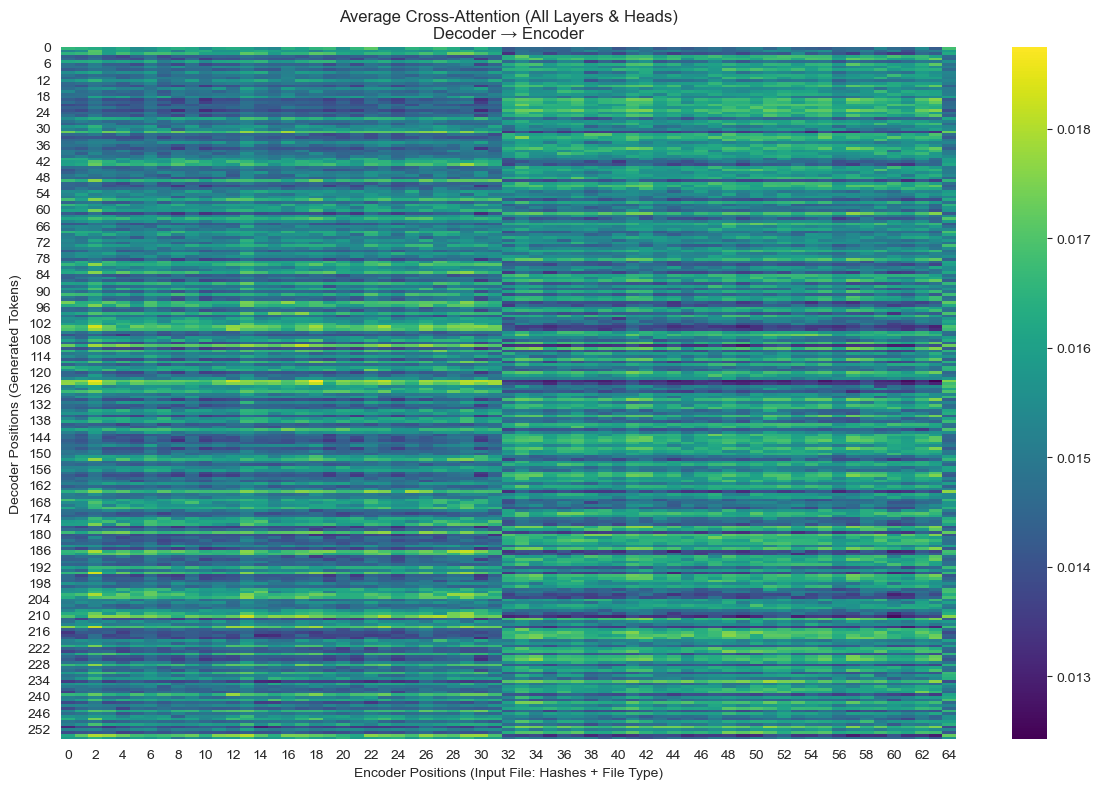

Усреднённая cross-attention сохранена: avg_cross_attention.png
  Размер: (256, 65) (decoder_seq_len × encoder_seq_len)


In [40]:
avg_matrix = visualize_avg_decoder_cross_attention(fileformer, masked_tokens, hash_tokens, ext_token, pads)